In [25]:
from IPython.display import HTML

HTML("""
<style>
/* override 'crit' style with gray fill and diagonal lines */
.mermaid .task.critical {
    fill: #ccc !important;
    fill-opacity: 0.8 !important;
    stroke: #888 !important;
    stroke-width: 1 !important;
}
</style>
""")




# Stock Wifi5 AP Capacity increase via non-intrusive volountary TDMA

The goal of this document is to determine if and quantify throughput improvements from implementing a Client only volountary TDMA scheme that can be used on stock Wifi5 APs (i.e. vendor agnostic), leveraging the beacon signal as a timing coordinator.

## Study Goals

As bandwidth usage increases, so too will contention collisions. 

We want to 

 1. model the collision dynamics
 2. predict specific performance curves and validate against real world data
 3. make predictions as to the effectiveness of a TDMA collision avoidance scheme
 4. figure out the maximum envelopes of such a schema


## Project Goals

- Supporting >100 clients per AP
- Sustaining > 80% throughput
- segregate uplink traffic from client traffic
- Dynamic reallocation of heavy consumers into seperate time segments to mitigate CSMA/CD

## Requirements

- entirely client side implemented and requires no customization to standard Wifi5 AP technology
- attempt to prevent collisions in the first instance, but on collision resort to CSMA/CD default behaviour

![Wifi](./NetworkDiagram.svg)

*Red nodes represent uplink antennas (also Clients to the AP), whereas blue nodes represent customer downlinks.*



## Model

We model the transmission characteristic of a single peer attempting to transmit on a network with a given congestion (measured as a fraction of full utilization). 

### TXOPs and Delivery Delay

A Transmission Opportunity (TXOP) occurs when we are able to transmit without collision. When a TXOP happens, the kernel outputs a single packet at MTU size (typically 1500bytes).

```mermaid
---
displayMode: compact
---
gantt
    title Network Utilization (ideal)
    tickInterval 10ms
    dateFormat  x
    axisFormat  %Lµs
    
    section Busy
	TX#0 : e0, 0, 53ms
	- : done, 53, 5ms
	TX#1 : e1, 58, 47ms
	- : done, 105, 5ms
	TX#2 : e2, 110, 59ms
	- : done, 169, 5ms
	TX#3 : e3, 174, 30ms
	- : done, 204, 5ms
	TX#4 : e4, 209, 53ms
	- : done, 262, 5ms
	TX#5 : e5, 267, 36ms

    section Moderate
	TX#0 : e0, 0, 25ms
	- : done, 25, 5ms
	TX#1 : e1, 70, 27ms
	- : done, 97, 5ms
	TX#2 : e2, 142, 22ms
	- : done, 164, 5ms
	TX#3 : e3, 209, 25ms
	- : done, 234, 5ms
	TX#4 : e4, 279, 31ms
	- : done, 310, 5ms

    section Light
	TX#0 : e0, 0, 35ms
	- : done, 35, 5ms
	TX#1 : e1, 100, 30ms
	- : done, 130, 5ms
	TX#2 : e2, 245, 35ms
    - : done, 280, 5ms
	
```


If there is a collision, a CSMA/CA backoff period is computed, i.e. a random delay is picked between [0, 2^n - 1] and a retransmission is attempted - where n represents the current collision count for this transmission attempt. This is repeated up to N retries.

```mermaid
---
displayMode: compact
---
gantt
    title Network Timing Diagram
    tickInterval 10ms
    dateFormat  x
    axisFormat  %Lµs
    
    section Network Traffic
	TX#0 : e0, 0, 13ms
	TX#1 : e1, 24, 15ms
	TX#2 : crit, e2, 57, 5ms
    CSMA/CD backoff: done, backoff, 62, 10ms
    TX#2 : e2_2, 72, 10ms
	TX#3 : e3, 107, 25ms
	TX#4 : e4, 148, 31ms

    section Peer
    Collision :crit, t1, 57, 5ms
    CSMA/CD backoff: done, backoff, 62, 30ms
    Re-transmit: t2, 92, 10ms

```

This diagram can be simplified even further to only consider two packets:

```mermaid
---
displayMode: compact
---
gantt
    title Timing Calculation
    tickInterval 10ms
    dateFormat  x
    axisFormat  %Lµs

    section Network Traffic
	TX#2 : crit, e2, 57, 5ms
    CSMA/CD backoff: done, backoff, 62, 10ms
    TX#2 : e2_2, 72, 10ms
	
    section Peer
    Collision : crit, t1, 57, 5ms
    CSMA/CD backoff: done, backoff, 62, 30ms
    Re-transmit: t2, 92, 10ms
```


### Throughput Calculation

Once a peer starts transmitting, it can transmit its entire payload unbroken. Assuming a payload of MTU sized bits (1500 bytes), the total throughput of the peer is calculated as the number of packets it can transmit per unit time (e.g. 100ms) multiplied by the data that can be transmitted.

If a peer can transmit $100$ packets per $100ms$, then its max throughput would be: $Bandwidth = 1500 bytes \cdot 8 bits \cdot 100 packets / 100ms = 12mbps$

If however link's throttled max throughput is `100mbps`, we infer that $c_{packets} = 100 mbps / 1500 bytes / 8 bits \cdot 100ms = 834 packets$. That is, $8.34 packets/ms$ must be sent to achieve design throughput.

Packets are approximately `15µs` in duration to send 1500bytes (MTU), and idle utilization interpacket gap is therefore $t_{gap}=(1ms / 8.34 packets) - 15µs \approx 104µs$. 

If the average expected delay time is $<104µs$, then the full $100mbps$ is attainable. However, as the expected delay time increases, we can compute the bandwidth drop so:

$$Bandwitdth=min(100mbps, 100mbps /  (t_{packet} + t_{delay}) / 8.34 )$$

If the delay time is 0ms, then we can achhieve max throughput (100mbps). If the expected delay is 10ms, 

In [112]:
# 802.11ac transmission burst limits
max_ppdu_duration = 5484  # μs - maximum Physical Protocol Data Unit time
max_symbols_per_burst = max_ppdu_duration / symbol_duration  # ~1371 symbols max

# But practical limits are much smaller due to:
max_ampdu_size = 1048576  # bytes (1MB) - Aggregated MAC Protocol Data Unit  
max_mpdu_count = 64  # maximum number of packets that can be aggregated

# packet aggregation (average scenario)
aggregated_packets = 10 * 1500 * 8  # 10 packets = 120,000 bits
symbols_needed = 77  # symbols - all sent in one burst

import math

def analyze_wifi_burst_timing():
    """
    Analyze timing for 10-packet A-MPDU burst with RTS/CTS protection
    """
    
    # === PACKET PARAMETERS ===
    packet_count = 10
    packet_size = 1500 * 8  # bits per packet
    total_data_bits = packet_count * packet_size  # 120,000 bits
    
    # === OFDM PARAMETERS ===
    symbol_duration = 4.0  # μs (802.11ac with long GI)
    symbol_capacity = 1560  # bits per symbol
    symbols_per_burst = math.ceil(total_data_bits / symbol_capacity)  # 77 symbols
    
    # === TIMING CONSTANTS (802.11ac) ===
    slot_duration = 9    # μs
    sifs = 16           # μs - Short Interframe Space
    difs = 34           # μs - DCF Interframe Space (SIFS + 2*slot)
    
    # === FRAME SIZES (bits) ===
    rts_size = 160      # 20 bytes * 8
    cts_size = 112      # 14 bytes * 8  
    block_ack_size = 256 # 32 bytes * 8 (Block ACK for 10 packets)
    
    # Calculate transmission durations
    rts_symbols = math.ceil(rts_size / symbol_capacity)
    cts_symbols = math.ceil(cts_size / symbol_capacity) 
    block_ack_symbols = math.ceil(block_ack_size / symbol_capacity)
    
    rts_duration = rts_symbols * symbol_duration
    cts_duration = cts_symbols * symbol_duration
    data_duration = symbols_per_burst * symbol_duration
    block_ack_duration = block_ack_symbols * symbol_duration
    
    print("=== 10-PACKET A-MPDU BURST TIMING ANALYSIS ===")
    print(f"Total Data: {packet_count} packets × {packet_size//8} bytes = {total_data_bits//8:,} bytes")
    print(f"OFDM Symbols Required: {symbols_per_burst} symbols")
    print()
    
    print("=== FRAME DURATIONS ===")
    print(f"RTS:       {rts_symbols} symbols × {symbol_duration} μs = {rts_duration:4.0f} μs")
    print(f"CTS:       {cts_symbols} symbols × {symbol_duration} μs = {cts_duration:4.0f} μs") 
    print(f"DATA:      {symbols_per_burst} symbols × {symbol_duration} μs = {data_duration:4.0f} μs")
    print(f"Block ACK: {block_ack_symbols} symbols × {symbol_duration} μs = {block_ack_duration:4.0f} μs")
    print()
    
    # === CONTENTION PHASE ===
    print("=== CONTENTION & TIMING SEQUENCE ===")
    
    # Typical contention window for data frames
    cw_min = 15  # slots
    avg_backoff_slots = cw_min / 2  # average backoff
    avg_backoff_time = avg_backoff_slots * slot_duration
    
    print("1. CONTENTION PHASE:")
    print(f"   - Wait for DIFS:     {difs:4.0f} μs")
    print(f"   - Average Backoff:   {avg_backoff_time:4.1f} μs ({avg_backoff_slots:.1f} slots)")
    print(f"   - Contention Total:  {difs + avg_backoff_time:4.1f} μs")
    print()
    
    # === TRANSMISSION SEQUENCE ===
    print("2. RTS/CTS EXCHANGE:")
    print(f"   - RTS transmission:  {rts_duration:4.0f} μs")
    print(f"   - SIFS wait:         {sifs:4.0f} μs")
    print(f"   - CTS transmission:  {cts_duration:4.0f} μs")
    print(f"   - SIFS wait:         {sifs:4.0f} μs")
    print(f"   - RTS/CTS Total:     {rts_duration + sifs + cts_duration + sifs:4.0f} μs")
    print()
    
    print("3. DATA TRANSMISSION:")
    print(f"   - A-MPDU burst:      {data_duration:4.0f} μs ({symbols_per_burst} symbols)")
    print(f"   - SIFS wait:         {sifs:4.0f} μs")
    print(f"   - Block ACK:         {block_ack_duration:4.0f} μs")
    print(f"   - Data Phase Total:  {data_duration + sifs + block_ack_duration:4.0f} μs")
    print()
    
    # === TOTAL TIMING ===
    total_contention = difs + avg_backoff_time
    total_rts_cts = rts_duration + sifs + cts_duration + sifs
    total_data_phase = data_duration + sifs + block_ack_duration
    total_transmission_time = total_contention + total_rts_cts + total_data_phase
    
    print("=== TOTAL TIMING BREAKDOWN ===")
    print(f"Contention Phase:    {total_contention:6.1f} μs ({total_contention/total_transmission_time*100:4.1f}%)")
    print(f"RTS/CTS Exchange:    {total_rts_cts:6.0f} μs ({total_rts_cts/total_transmission_time*100:4.1f}%)")
    print(f"Data + Block ACK:    {total_data_phase:6.0f} μs ({total_data_phase/total_transmission_time*100:4.1f}%)")
    print(f"TOTAL TIME:          {total_transmission_time:6.1f} μs")
    print()
    
    # === EFFICIENCY ANALYSIS ===
    useful_data_time = data_duration
    efficiency = (useful_data_time / total_transmission_time) * 100
    effective_throughput = (total_data_bits / total_transmission_time)  # Mbps (since μs cancels)
    
    print("=== EFFICIENCY ANALYSIS ===")
    print(f"Useful Data Time:    {useful_data_time:6.0f} μs")
    print(f"Overhead Time:       {total_transmission_time - useful_data_time:6.1f} μs")
    print(f"MAC Efficiency:      {efficiency:6.1f}%")
    print(f"Effective Throughput: {effective_throughput:5.1f} Mbps")
    print()
    
    # === COMPARISON TO SINGLE PACKETS ===
    print("=== AGGREGATION BENEFIT ===")
    
    # Single packet timing (without RTS/CTS for comparison)
    single_packet_symbols = math.ceil(packet_size / symbol_capacity)
    single_packet_data_time = single_packet_symbols * symbol_duration
    single_packet_ack_time = math.ceil(112 / symbol_capacity) * symbol_duration  # regular ACK
    single_packet_total = difs + avg_backoff_time + single_packet_data_time + sifs + single_packet_ack_time
    
    # 10 separate transmissions
    ten_separate_total = 10 * single_packet_total
    
    print(f"10 separate packets: {ten_separate_total:6.0f} μs")
    print(f"1 aggregated burst:  {total_transmission_time:6.1f} μs") 
    print(f"Aggregation saves:   {ten_separate_total - total_transmission_time:6.0f} μs ({(ten_separate_total/total_transmission_time - 1)*100:.0f}% faster)")
    
    return {
        'total_time_us': total_transmission_time,
        'data_time_us': data_duration,
        'efficiency_percent': efficiency,
        'throughput_mbps': effective_throughput,
        'symbols_transmitted': symbols_per_burst
    }

result = analyze_wifi_burst_timing()

=== 10-PACKET A-MPDU BURST TIMING ANALYSIS ===
Total Data: 10 packets × 1500 bytes = 15,000 bytes
OFDM Symbols Required: 77 symbols

=== FRAME DURATIONS ===
RTS:       1 symbols × 4.0 μs =    4 μs
CTS:       1 symbols × 4.0 μs =    4 μs
DATA:      77 symbols × 4.0 μs =  308 μs
Block ACK: 1 symbols × 4.0 μs =    4 μs

=== CONTENTION & TIMING SEQUENCE ===
1. CONTENTION PHASE:
   - Wait for DIFS:       34 μs
   - Average Backoff:   67.5 μs (7.5 slots)
   - Contention Total:  101.5 μs

2. RTS/CTS EXCHANGE:
   - RTS transmission:     4 μs
   - SIFS wait:           16 μs
   - CTS transmission:     4 μs
   - SIFS wait:           16 μs
   - RTS/CTS Total:       40 μs

3. DATA TRANSMISSION:
   - A-MPDU burst:       308 μs (77 symbols)
   - SIFS wait:           16 μs
   - Block ACK:            4 μs
   - Data Phase Total:   328 μs

=== TOTAL TIMING BREAKDOWN ===
Contention Phase:     101.5 μs (21.6%)
RTS/CTS Exchange:        40 μs ( 8.5%)
Data + Block ACK:       328 μs (69.9%)
TOTAL TIME:        

In [107]:
def compute_bandwidth(delay): # delay in microseonds
    return np.clip(0, 100, 100.0 / ((delay + 15) / 1000) / 8.34)

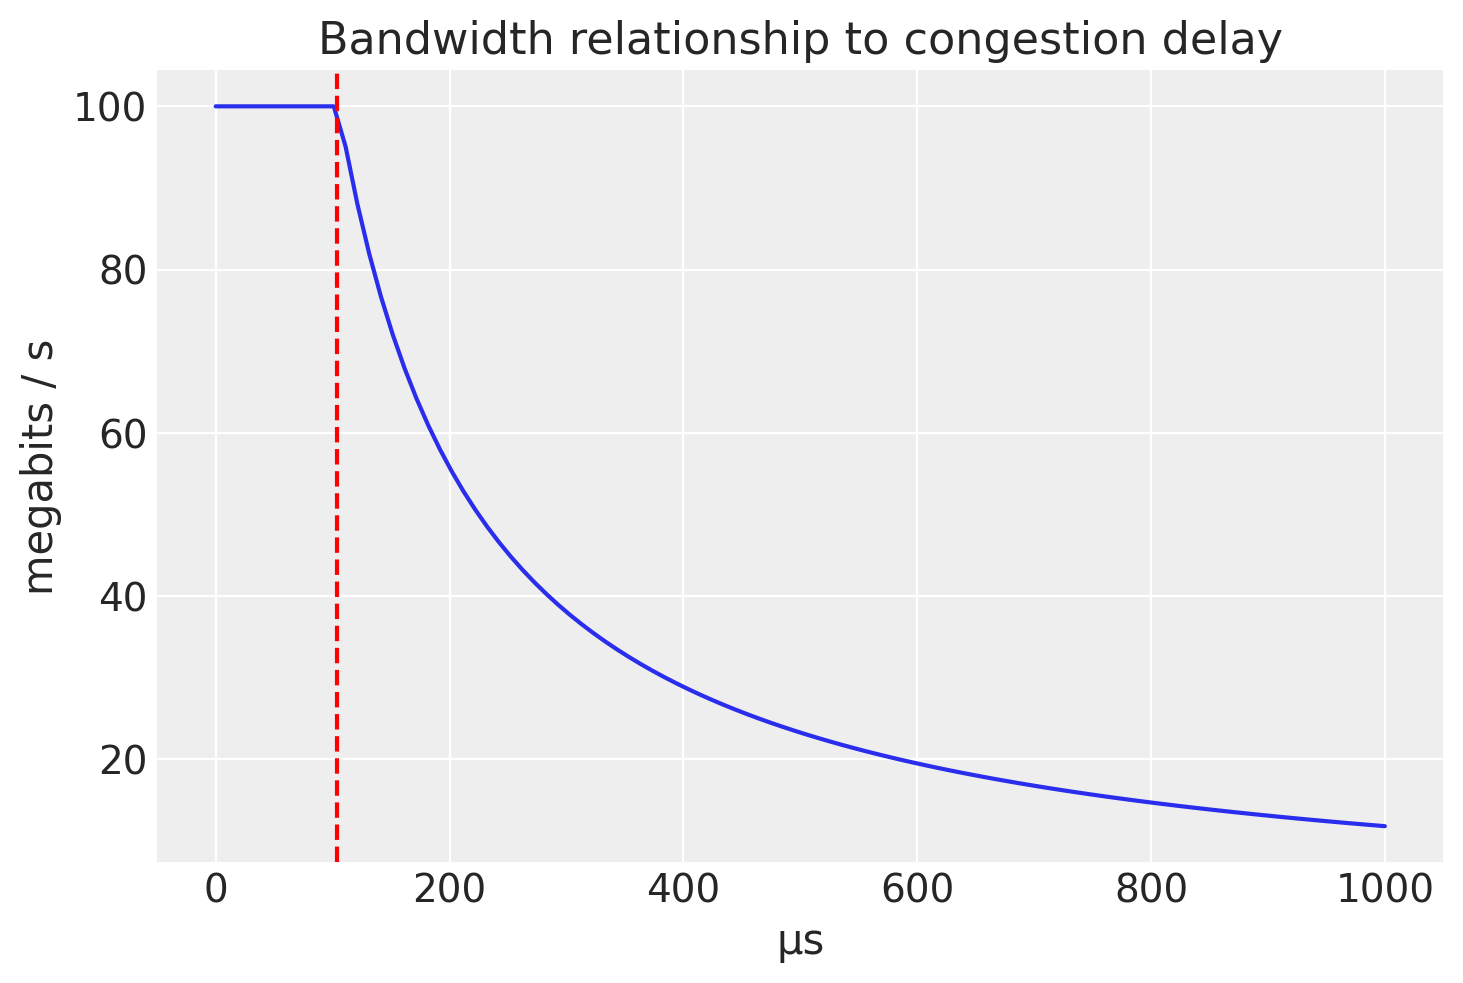

In [90]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

X = np.linspace(0, 1000, 100)
plt.plot( X, compute_bandwidth(X), label="Max Bandwidth given collision latency")
plt.axvline( 104, linestyle="--", color="red")
plt.title("Bandwidth relationship to congestion delay")
plt.ylabel("megabits / s")
plt.xlabel("µs")
_ = _

The total duration of delay due to congestion at time $t$ is: 

$$T_{t} = P( collision_t | transmission_t ) \cdot \tau_{0} + P( collision_{t+\tau_{0}} | transmission_{t+\tau{0}}) \cdot \tau_{1} + ... + P( collision_{t+\tau_{n-1}} | transmission_{t+\tau{n-1}}) \cdot \tau_{n}$$

where $\tau_{n}$ is picked uniformly between $[0;2^n - 1]$ times transmission time of $4µs$, and $n$ goes from 0 to `retry`.


In [123]:
import random
TT = [random.randint(100,160) if i > 0 else 0 for i in range(6)]
for i, (x, dt) in enumerate(zip(np.cumsum(TT), TT[1:])):
    print(f"\tTX#{i} : e{i}, {x}, {dt-45}ms")
    print(f"\t- : done, {x + dt -45}, 5ms")

	TX#0 : e0, 0, 57ms
	- : done, 57, 5ms
	TX#1 : e1, 102, 76ms
	- : done, 178, 5ms
	TX#2 : e2, 223, 90ms
	- : done, 313, 5ms
	TX#3 : e3, 358, 62ms
	- : done, 420, 5ms
	TX#4 : e4, 465, 85ms
	- : done, 550, 5ms


In [195]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import pytensor.tensor as at

import arviz as az

RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")


In [196]:
link_rate = 780  # Mbps
uplink_count = 1 
client_count = 9 
client_rate = 100 
network_utilization = 0.4
cw_min = 15  # μs  - 802.11ac minimum contention window
retry_count = 10

# OFDM magic numbers
symbol_duration = 4.0  # μs (802.11ac OFDM symbol time)
symbol_capacity = 1560  # bits per symbol (256-QAM, 234 subcarriers, 5/6 coding)
channels = 2 # MIMO
slot_duration = 9  # μs  (802.11ac slot time)

# packet = one continuous transmission

# A-MPDU (Aggregated MPDUs) - 802.11ac
symbols_per_packet = 10 #  5378 maximum theoretical - above regulation

tx_overhead = 114 # μs - DIFS + (preamble + headers) + SIFS + ACK
                  #       34μs           40μs           16μs  24μs

# backoff_time = N x slot_duration # μs

data_tx_duration = symbol_duration * symbols_per_packet  # 40 μs (data only)
total_packet_duration = data_tx_duration + tx_overhead      # 154 μs (complete)
packet_size_bits = symbol_capacity * symbols_per_packet * channels  # total bits
packet_size_bytes = packet_size_bits / 8                # bytes

print(f"Packet transmission duration: {packet_tx_duration} μs")
print(f"Symbols per packet: {symbols_per_packet}")
print(f"Bytes per packet: {packet_size * symbols_per_packet:.0f}")
print(f"Full bandwidth with no delay: {1/packet_tx_duration*packet_size * symbols_per_packet}")
print(f"Full bandwidth with no delay: {1/(packet_tx_duration+135)*packet_size * symbols_per_packet}")


Packet transmission duration: 3.2e-05 μs
Symbols per packet: 10
Bytes per packet: 120000
Full bandwidth with no delay: 3750000000.0
Full bandwidth with no delay: 888.8886781893505


In [271]:
# OFDM magic numbers
cw_min = 15  # 802.11ac minimum contention window
retry_count = 10

# device 
qam = 8 # 256-QAM
carriers = 234 # out of 256 carriers
coding = 5/6
channels = 2 # MIMO

symbol_duration = 4.0  # μs (802.11ac OFDM symbol time)
slot_duration = 9  # μs  (802.11ac slot time)
symbol_capacity = qam * carriers * coding * channels # bits per symbol (256-QAM, 234 subcarriers, 5/6 coding)

# packet = one continuous transmission

# A-MPDU (Aggregated MPDUs) - 802.11ac
# symbols_per_packet = 10 -> 5378 maximum theoretical - above regulation

tx_overhead = 114 # μs - DIFS + (preamble + headers) + SIFS + ACK
                  #       34μs           40μs           16μs  24μs

network_utilization = np.linspace(0, 1, 11)
symbols_per_packet = np.asarray([1,2, 4, 8, 16, 32, 64])
retry_count = 10

tdma_channels = 6

with pm.Model() as model:
    # Create parameter coordinate tensors
    utilization_coords = pm.Data("utilization_coords", network_utilization)
    symbols_coords = pm.Data("symbols_coords", symbols_per_packet)
    
    # Expand dimensions: [n_utils, n_symbols, retry_count]
    # Network busy probability for each utilization level
    busy = pm.Bernoulli("busy", p=utilization_coords[:, None, None] / tdma_channels,  # Shape: [n_utils, 1, 1] broadcasts to [n_utils, n_symbols, retry_count]
                                shape=(len(network_utilization), len(symbols_per_packet), retry_count))
    
    # Backoff delays - same across all parameter combinations
    delay = pm.Uniform("delay", lower=0,
                                upper=np.minimum(cw_min * (2**np.arange(retry_count)), 1023)[None, None, :],
                                shape=(len(network_utilization), len(symbols_per_packet), retry_count))
    
    # Calculate packet properties for each symbol count
    packet_sizes = symbols_per_packet * symbol_capacity  # bits
    data_tx_durations = symbols_per_packet * symbol_duration  # μs
    
    # Contention delays - vectorized across all combinations
    contention_delay_0 = pm.Deterministic("contention_delay_0", pm.math.switch(busy[:, :, 0], 
                                                                               delay[:, :, 0] * slot_duration, 0))
    
    contention_delays = [contention_delay_0]
    for n in range(1, retry_count):
        _ = pm.Deterministic(f"contention_delay_{n}", pm.math.switch(busy[:, :, n].astype(bool) & (at.neq(contention_delays[n-1], 0)),
                                                                    delay[:, :, n] * slot_duration, 0))
        contention_delays.append(_)
    
    # Total delays across all parameter combinations
    total_contention_delay = pm.Deterministic("total_delay", sum(contention_delays))  # Shape: [n_utils, n_symbols]
    
    # Total transmission duration for each combination
    total_transmission_duration = pm.Deterministic("transmission_duration", total_contention_delay +  tx_overhead +  data_tx_durations[None, :])  # Broadcast data_durations
    
    # Bandwidth for each combination
    max_bandwidth = pm.Deterministic("max_bandwidth", packet_sizes[None, :] / tdma_channels / total_transmission_duration)  # Shape: [n_utils, n_symbols]
    
    # Sample
    trace = pm.sample(draws=1000, tune=500, chains=2, target_accept=0.95)
    

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>BinaryGibbsMetropolis: [busy]
>NUTS: [delay]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 21 seconds.
/home/memet/.local/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


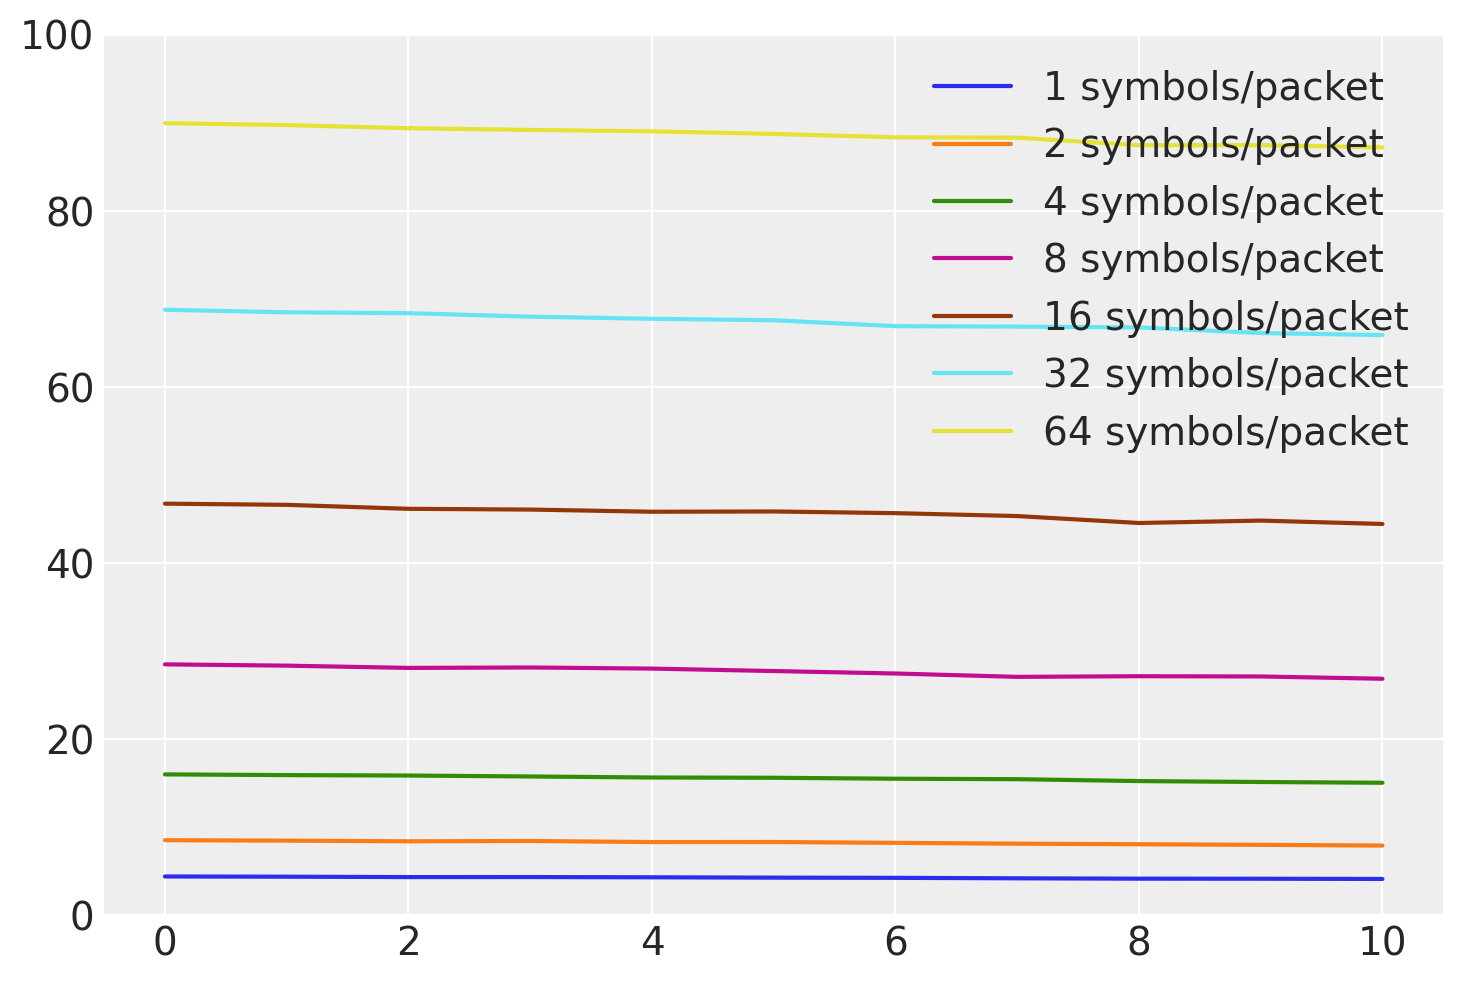

In [272]:

for i, s in enumerate(symbols_per_packet):
    plt.plot(trace.posterior["max_bandwidth"][:,:,:,i].mean(axis=1)[0,:].clip(0,100), label=f"{s} symbols/packet")
plt.ylim(0,100)
plt.legend()

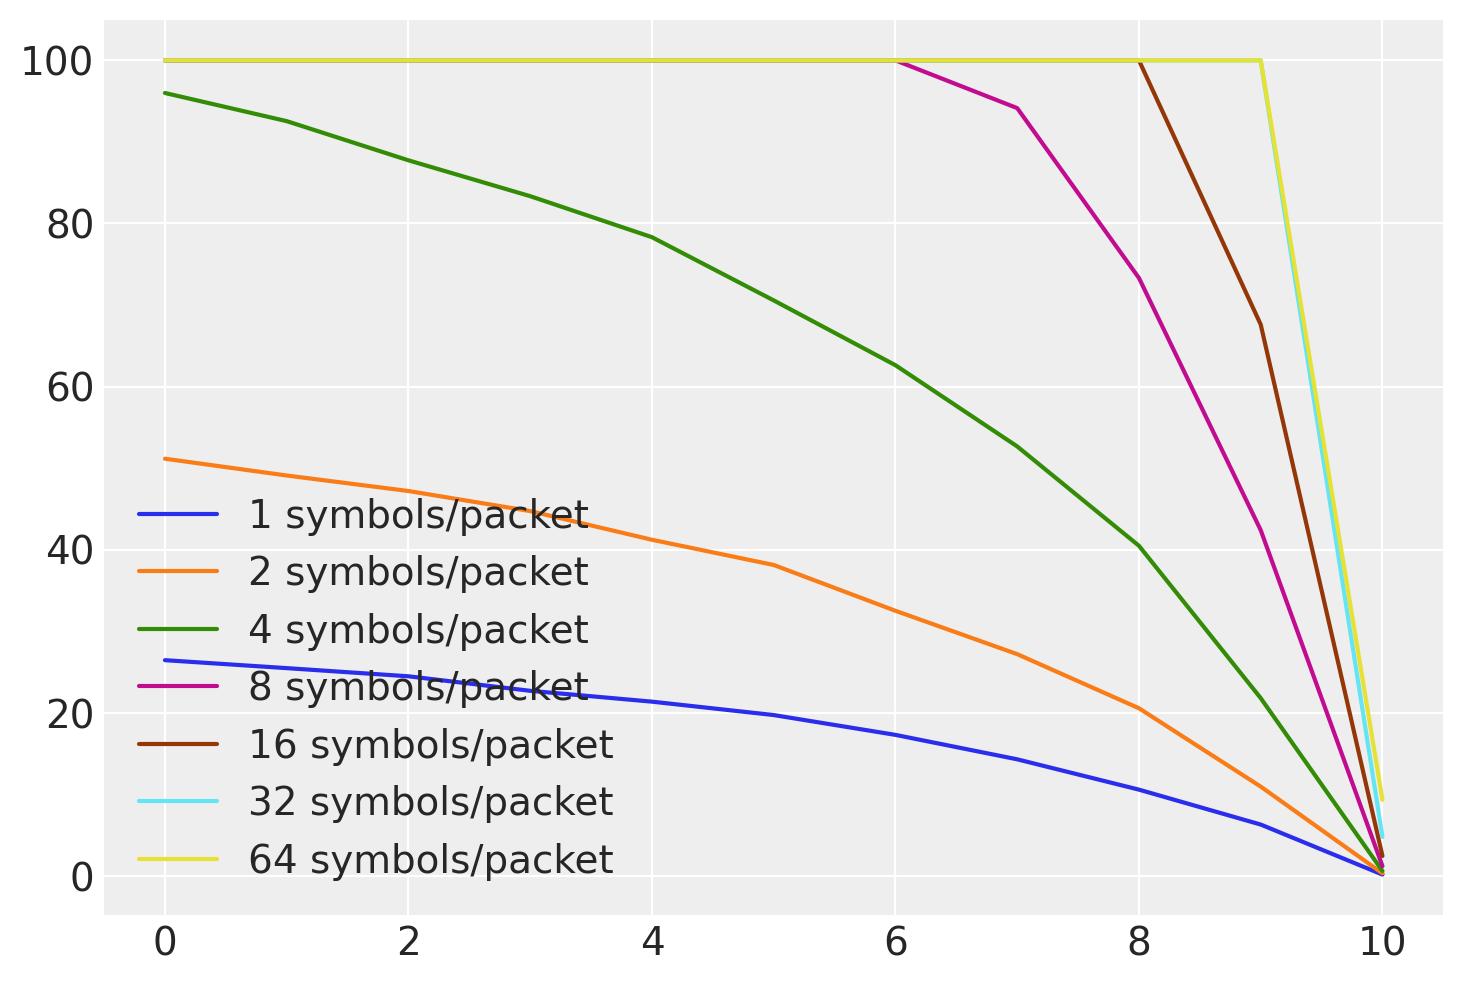

In [264]:
#az.summary(trace.posterior["max_bandwidth"][:,:,:,4])
#az.plot_posterior( trace.posterior["max_bandwidth"][:, :, :, 1]) # 1 std dev equivalent)

for i, s in enumerate(symbols_per_packet):
    plt.plot(trace.posterior["max_bandwidth"][:,:,:,i].mean(axis=1)[0,:].clip(0,100), label=f"{s} symbols/packet")
plt.legend()

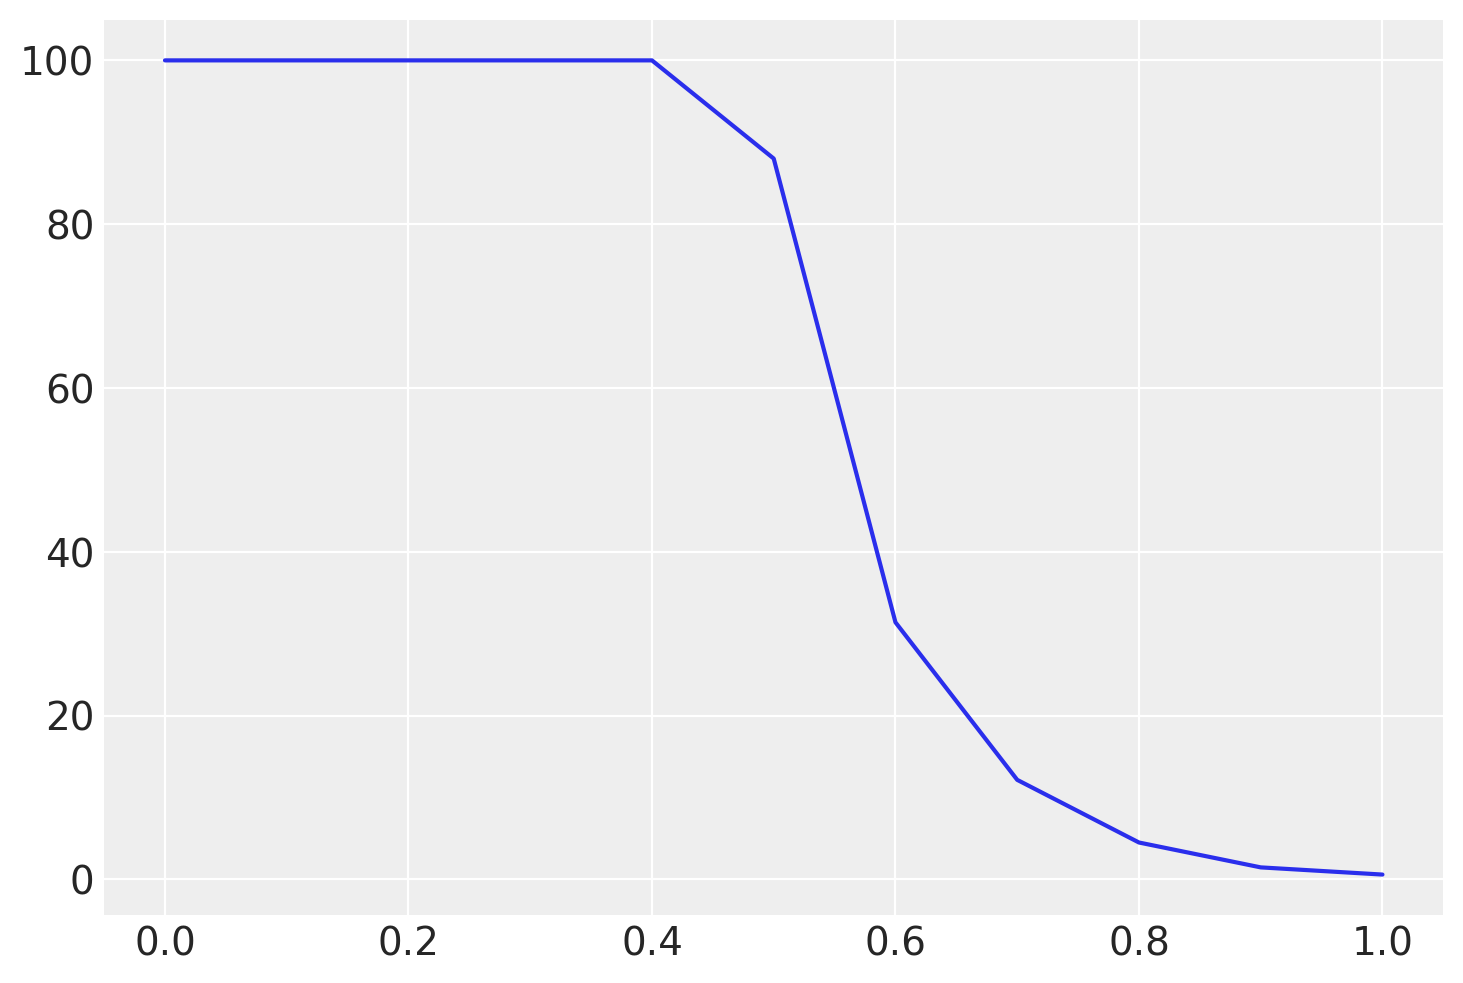

In [106]:
plt.plot(X, Y)

/home/memet/.local/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/memet/.local/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/memet/.local/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/memet/.local/lib/python3.13/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/memet/.local/lib/python3.13/site-packages/arviz/st

array([[<Axes: title={'center': 'busy'}>,
        <Axes: title={'center': 'busy'}>],
       [<Axes: title={'center': 'delay'}>,
        <Axes: title={'center': 'delay'}>],
       [<Axes: title={'center': 'contention_delay_0'}>,
        <Axes: title={'center': 'contention_delay_0'}>],
       [<Axes: title={'center': 'contention_delay_1'}>,
        <Axes: title={'center': 'contention_delay_1'}>],
       [<Axes: title={'center': 'contention_delay_2'}>,
        <Axes: title={'center': 'contention_delay_2'}>],
       [<Axes: title={'center': 'contention_delay_3'}>,
        <Axes: title={'center': 'contention_delay_3'}>],
       [<Axes: title={'center': 'contention_delay_4'}>,
        <Axes: title={'center': 'contention_delay_4'}>],
       [<Axes: title={'center': 'contention_delay_5'}>,
        <Axes: title={'center': 'contention_delay_5'}>],
       [<Axes: title={'center': 'contention_delay_6'}>,
        <Axes: title={'center': 'contention_delay_6'}>],
       [<Axes: title={'center': 'cont

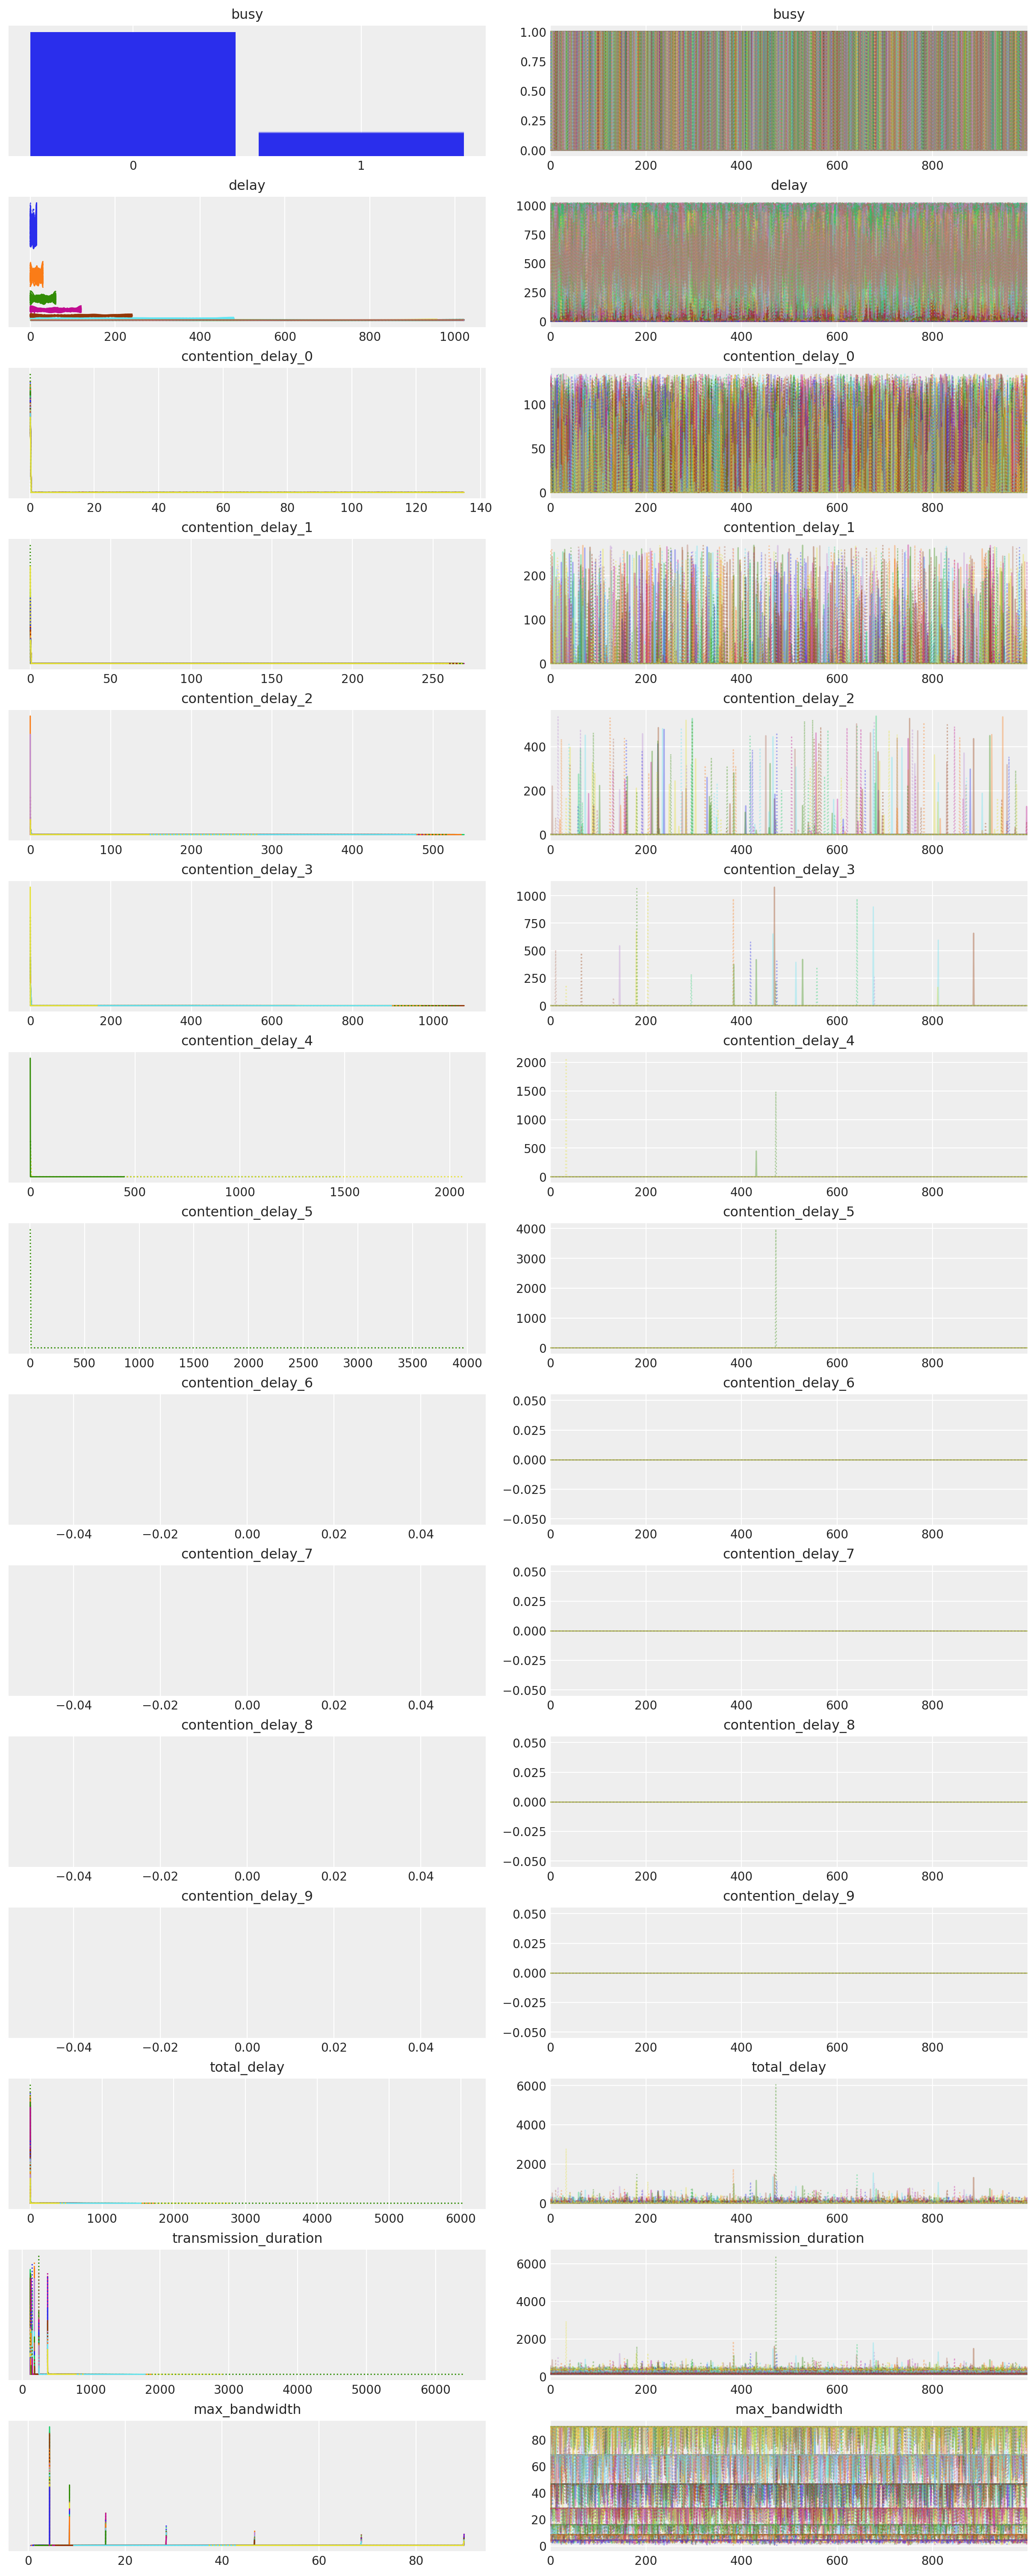

In [273]:
az.plot_trace(data=trace)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [p_collision]


Output()

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
T_t,0.000,0.000,0.000,0.000,0.000,0.000,2096.0,1557.0,1.00
p_collision[0],0.291,0.167,0.014,0.595,0.003,0.004,2490.0,1075.0,1.00
p_collision[1],0.287,0.166,0.019,0.571,0.003,0.004,2336.0,1200.0,1.01
p_collision[2],0.285,0.156,0.017,0.553,0.003,0.004,2503.0,1356.0,1.00
p_collision[3],0.287,0.160,0.024,0.569,0.003,0.003,2093.0,1284.0,1.00
p_collision[4],0.285,0.156,0.016,0.560,0.003,0.003,1957.0,1098.0,1.00


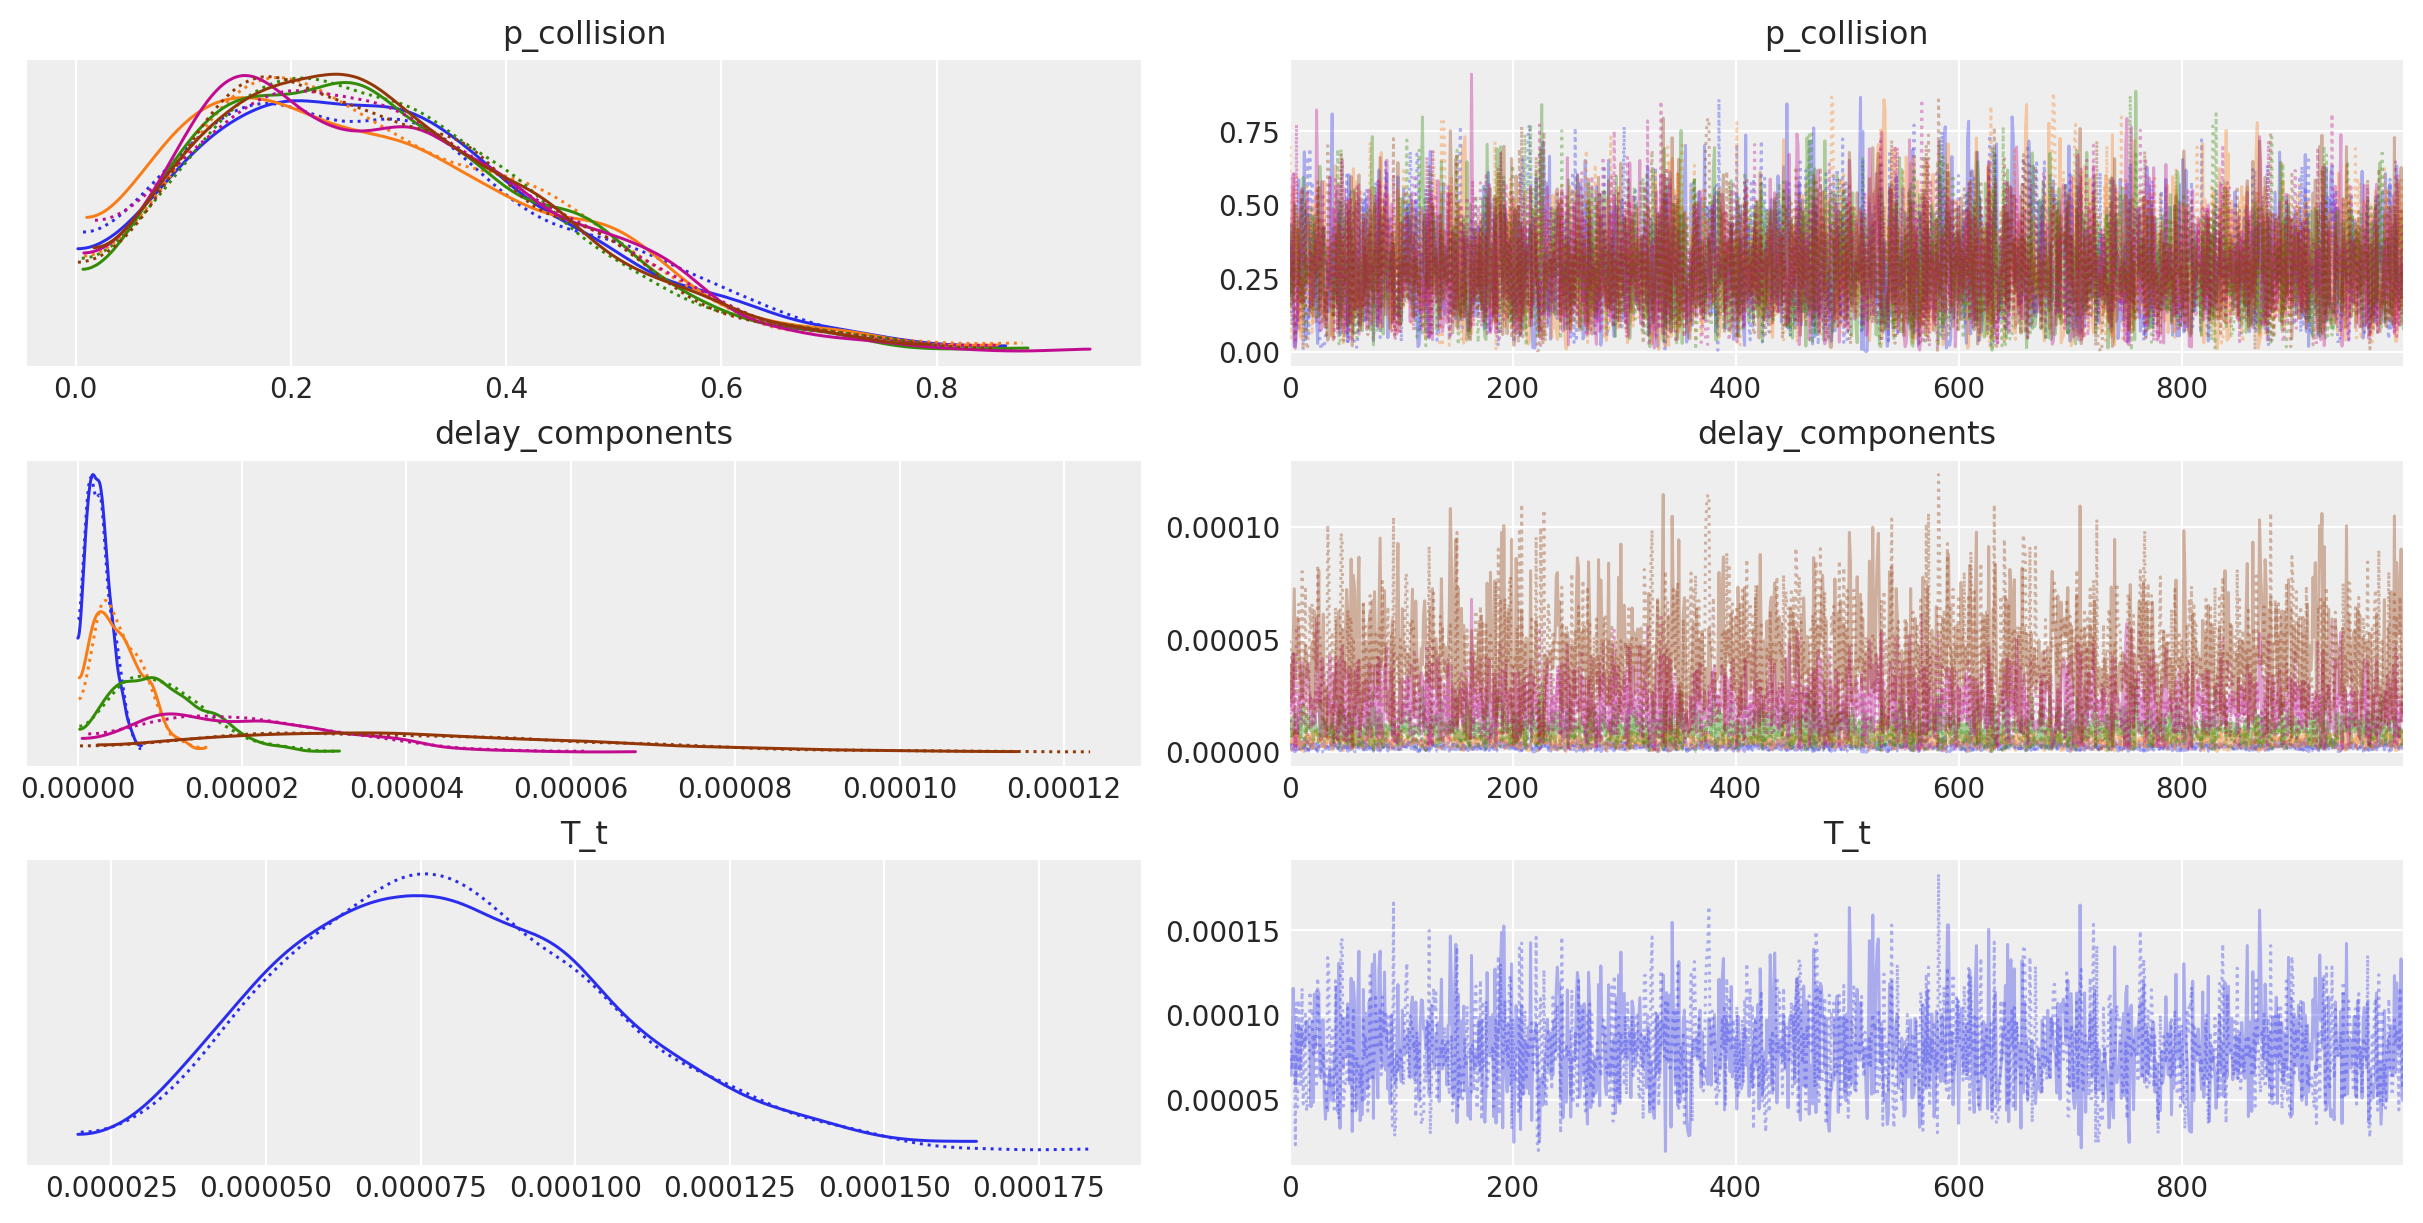

In [44]:
# Parameters
n = 5  # max retries
tau = np.array([2**i for i in range(n)])  # exponential backoff slots
slot_time = 9e-6  # 9μs typical slot time
tau_durations = tau * slot_time

with pm.Model() as model:
    # Prior: probability of collision at each backoff stage
    p_collision = pm.Beta('p_collision', alpha=2, beta=5, shape=n)

    # Compute expected delay T_t
    delay_components = pm.Deterministic(
        'delay_components', p_collision * tau_durations
    )

    T_t = pm.Deterministic('T_t', pm.math.sum(delay_components))

    trace = pm.sample(draws=1000, tune=500, chains=2, target_accept=0.95)

# Quick posterior check
import arviz as az
az.plot_trace(data=trace);
az.summary(trace, var_names=["T_t", "p_collision"])

In [45]:


def create_collision_chart(max_speed=100, client_count=1, uplink_count=1, time_per_symbol=4e-6, symbol_capacity=1560, channels=2):
    # compute rate of collisions given uniform timing distribution ranging from 0 utilization to full utilization at max_speed
    # all computations are per-second
    X = np.linspace(0, max_speed, 10)
    Y = np.zeros_like(X)
    total_count = uplink_count + client_count
    symbols_per_sec_total = 1 / (symbol_capacity * 8)
    symbols_per_sec_per_client = symbols_per_sec_total / client_count
    symbols_per_channel = symbols_per_sec_total / channels
    
    for i,x in enumerate(X):
        utilization = x * 1e6 * symbols_per_channel * time_per_symbol
        collision_prob = max(0, 1 - np.exp(-client_count * utilization / total_count))
        Y[i] = collision_prob
    return X, Y


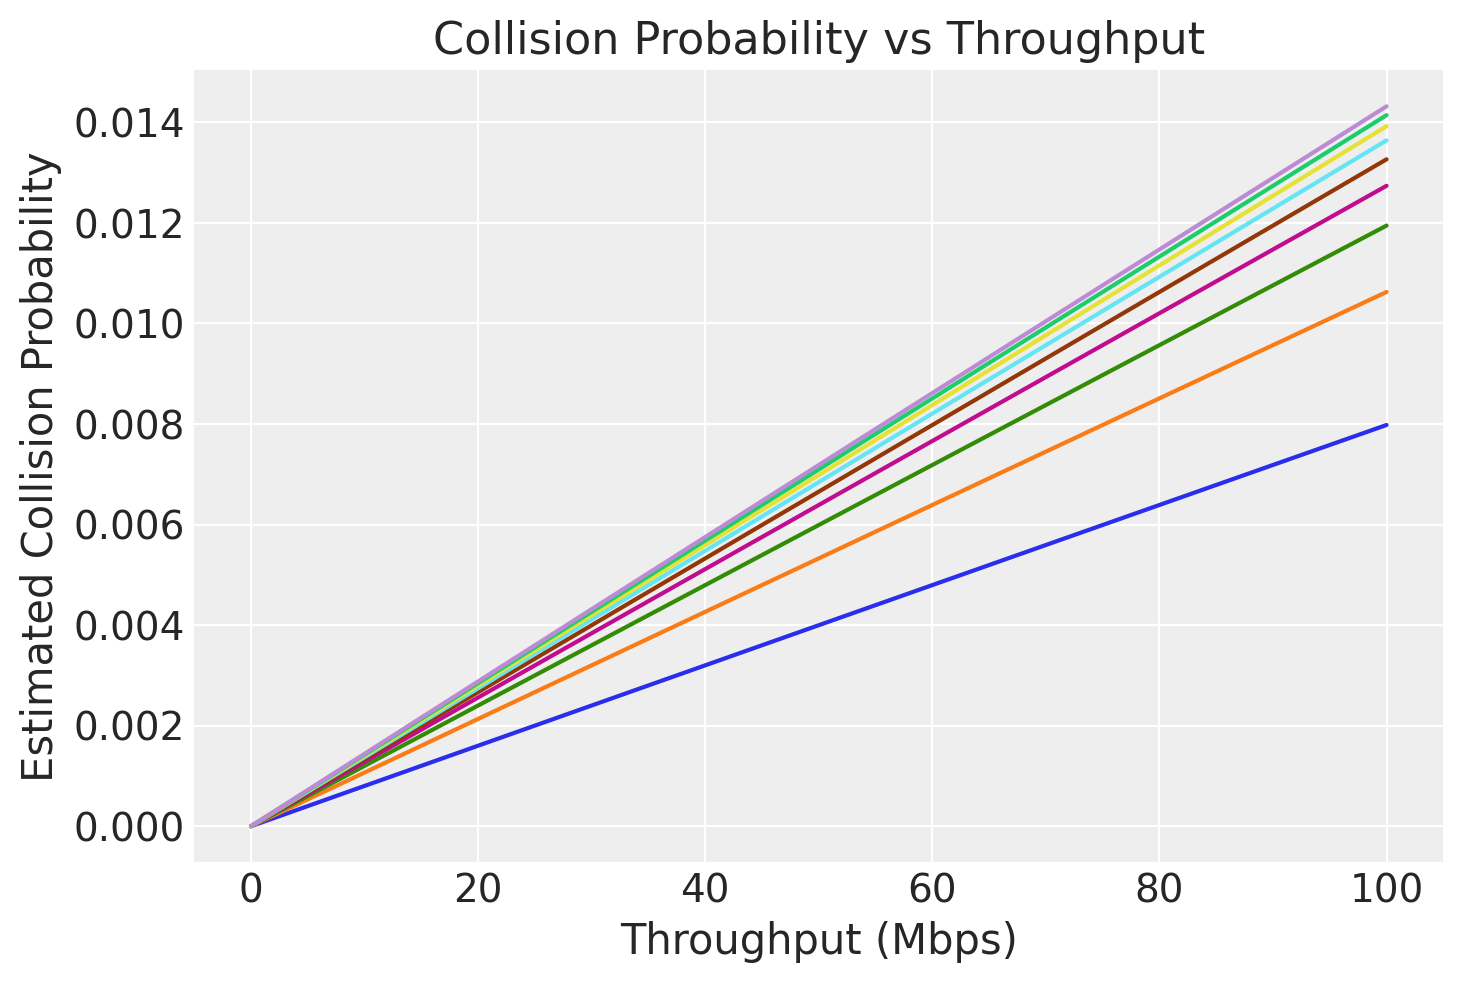

In [46]:
uplinks = [1, 1, 1, 1, 1, 1, 1, 1, 1]
clients = [1, 2, 3, 4, 5, 6, 7, 8, 9]

plt.xlabel("Throughput (Mbps)")
plt.ylabel("Estimated Collision Probability")
plt.title("Collision Probability vs Throughput")
plt.grid(True)
for client in range(1, 10):
    plt.plot(*create_collision_chart(client_count=client), label=f"{client} clients")

plt.show()

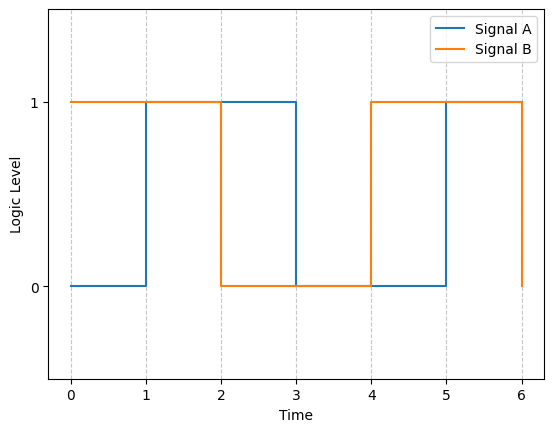

In [24]:
# Example timing diagram signals
time = [0, 1, 2, 3, 4, 5, 6]
signal_A = [0, 1, 1, 0, 0, 1, 1]
signal_B = [1, 1, 0, 0, 1, 1, 0]

plt.step(time, signal_A, where='post', label='Signal A')
plt.step(time, signal_B, where='post', label='Signal B')

plt.fill_between(time, signal_A, 0, where=np.logical_and(signal_A, np.logical_not(signal_B)), step="pre", alpha=0.4)
plt.fill_between(time, signal_B, 0, where=np.logical_and(signal_B, np.logical_not(signal_A)), step="pre", alpha=0.4)
plt.fill_between(time, signal_B, 0, where=np.logical_and(signal_A, signal_B), step="pre", alpha=0.4)

plt.ylim(-0.5, 1.5)
plt.yticks([0, 1])
plt.xlabel('Time')
plt.ylabel('Logic Level')
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

In [2]:
import pymc

In [2]:
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0, sigma=1)
    obs = pm.Normal("obs", mu=mu, sigma=1, observed=rng.standard_normal(100))

In [3]:
model.basic_RVs

[mu ~ Normal(0, 1), obs ~ Normal(mu, 1)]

In [4]:
model.free_RVs

[mu ~ Normal(0, 1)]

In [5]:
model.compile_logp()({"mu": 0})

array(-143.03962875)

In [6]:
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0, sigma=1)
    sd = pm.HalfNormal("sd", sigma=1)
    obs = pm.Normal("obs", mu=mu, sigma=sd, observed=rng.standard_normal(100))

    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sd]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


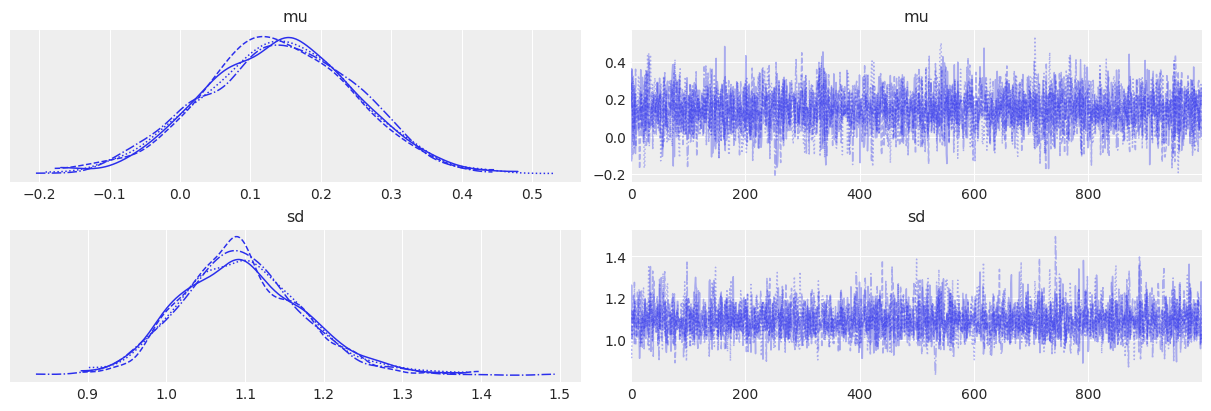

In [7]:
az.plot_trace(idata);